# **Học phần mở rộng cho môn học máy: Mô hình Markov ẩn**
**Nhóm**: CEML1

**Môn học**: CO3117 - Machine Learning

**Lớp**: TN01

**Giảng viên hướng dẫn**: Lê Thành Sách

**Chủ đề**: Sử dụng mô hình Markov trong bài toán phân loại tiếng nói (Spoken digit recognition)

**Deadline**: 13/12/2025

**Github**: https://github.com/ChiThanh512/Machine-Learning-Project-251---CEML1.git

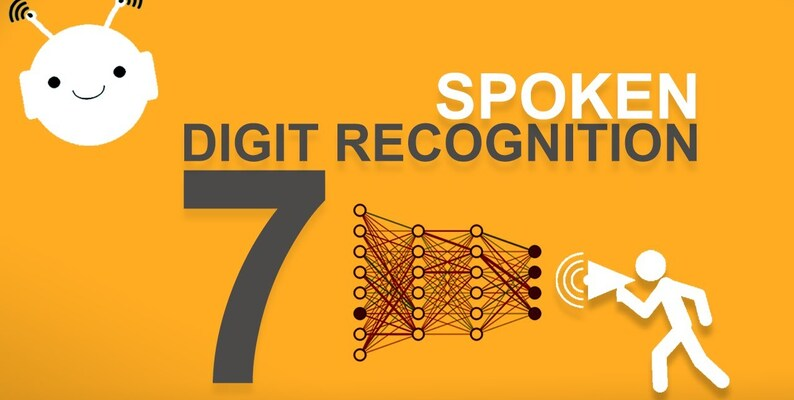


##**SPOKEN DIGIT RECOGNITON**
Tổng quan bài toán mà nhóm phải xử lý là từ dữ liệu âm thanh đã được đánh nhãn, sử dụng giải thuật HMM để xây dựng mô hình nhận diện âm thanh xem đoạn âm thanh đang là con số (digit) nào.

### Các giai đoạn của dự án

1.   EDA(Exploratory Data Analysis): Thống kê mô tả, trực quan hóa,...
2.   Trích xuất đặc trưng
3.   Xây dựng mô hình HMM

##Mục tiêu
Xây dựng Pipeline học máy truyền thống cho vấn đề trên.
1.  **EDA (Exploratory Data Analysis):**
    *   Thống kê mô tả dữ liệu, trực quan hóa để hiểu rõ các biến.
    *   Phát hiện dữ liệu thiếu.
    *   Quan sát các hình dáng âm thanh trong miền thời gian, miền phổ và miền MFCC

2.  **Tiền xử lý dữ liệu (Data Preprocessing):**
    *   Làm sạch dữ liệu, xử lý các giá trị bị thiếu.
    *   Trích xuất âm thanh thành các chuỗi quan sát (MFCC,MFCC-delta 1, MFCC-delta 2)
    *   Chuẩn hóa dữ liệu số (StandardScaler).
    *   Chia tập dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test).
3. **Trích xuất và lựa chọn đặc trưng (Feature Engineering & Selection):**
    *   Trích xuất âm thanh thành các chuỗi quan sát (MFCC,MFCC-delta 1, MFCC-delta 2)
    *   Chuẩn hóa dữ liệu số (StandardScaler).
    *   Chia tập dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test).

4.  **Huấn luyện mô hình (Model Training):** Xây dựng mô hình HMM

5.  **Đánh giá mô hình (Model Evaluation):** Dựa trên các thông số accuracy, F1-score.




## **Giới thiệu đề tài**

Nhiệm vụ của nhóm tập trung vào bài toán **nhận dạng số (Spoken digit recognition)** từ dữ liệu dạng âm thanh (Kaggle). Mục tiêu là xây dựng một **pipeline học máy truyền thống** có thể cấu hình linh hoạt cho từng bước: **EDA → tiền xử lý → trích xuất & lựa chọn đặc trưng → huấn luyện → đánh giá**.

Bộ dữ liệu là 17000 mẫu âm thanh phát âm các số từ (0-9). Phân bố dữ liệu của tập này là cân bằng khi số đều có số lượng mẫu bằng nhau. Nguồn dữ liệu: https://www.kaggle.com/datasets/subhajournal/free-spoken-digit-database

Mục tiêu của nhóm là xây dựng 10 mô hình HMM để tính xác xuất của tệp âm thanh thuộc về mô hình nào là cao nhất.




# 1.Thiết lập môi trường và tải dữ liệu
## 1.1 Nhập các thư viện cần thiết

In [31]:
import librosa
import librosa.display as dsp
from IPython.display import Audio
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [32]:
# 1. Quay về thư mục gốc của Colab để đảm bảo vị trí đúng
%cd /content

# 2. Xóa thư mục dự án cũ đi nếu nó tồn tại (đây chính là bước "ghi đè")
PROJECT_DIR = 'project_dir'
if os.path.exists(PROJECT_DIR):
    print(f"Thư mục '{PROJECT_DIR}' đã tồn tại. Đang xóa để ghi đè...")
    !rm -rf {PROJECT_DIR}

# 3. Tạo lại thư mục dự án và di chuyển vào đó
print(f"Tạo thư mục mới '{PROJECT_DIR}'...")
!mkdir {PROJECT_DIR}
%cd {PROJECT_DIR}

# 4. Khởi tạo git và tải code bằng sparse checkout
print("Đang tải code từ GitHub...")
!git init
!git remote add origin https://github.com/ChiThanh512/Machine-Learning-Project-251---CEML1.git
!git config core.sparsecheckout true
!echo "HPMR/" >> .git/info/sparse-checkout
!git pull origin main

# 5. Kiểm tra kết quả
print("\n--- Cấu trúc thư mục sau khi tải: ---")
!ls -R

/content
Thư mục 'project_dir' đã tồn tại. Đang xóa để ghi đè...
Tạo thư mục mới 'project_dir'...
/content/project_dir
Đang tải code từ GitHub...
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/project_dir/.git/
remote: Enumerating objects: 743, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 743 (delta 116), reused 151 (delta 67), pack-reused 515 (from 3)
Receiving objects: 100% (743/743), 168.95 MiB | 36.44 MiB/s, done.
Resolving deltas: 100

In [33]:
# Thêm đường dẫn đến thư mục HPMR vào sys.path
hpmr_path = os.path.abspath('HPMR')
if hpmr_path not in sys.path:
    sys.path.append(hpmr_path)
    print(f"Đã thêm '{hpmr_path}' vào sys.path")

# Import hàm download từ module data_loader
from modules.data_loader import download_kaggle_dataset
from modules.preprocessing import read_dataset_and_save_feture
!pip install hmmlearn

In [34]:
# --- Cấu hình ---
KAGGLE_USER = 'nguyenk512'
KAGGLE_API_KEY = '187454a718c857637f7319f39e33b509'
DATASET_TO_DOWNLOAD = 'subhajournal/free-spoken-digit-database'
TARGET_DIRECTORY = './HPMR/spoken_digit_data' # Thư mục sẽ được tạo bên trong project_dir

# --- Gọi hàm đã import ---
download_kaggle_dataset(
    dataset_name=DATASET_TO_DOWNLOAD,
    username=KAGGLE_USER,
    key=KAGGLE_API_KEY,
    download_dir=TARGET_DIRECTORY
)

--- Bắt đầu quá trình tải dataset từ Kaggle ---
1. Cài đặt thư viện Kaggle...
2. Thiết lập thông tin xác thực...
3. Đảm bảo thư mục './HPMR/spoken_digit_data' tồn tại...
4. Tải dataset 'subhajournal/free-spoken-digit-database'...
5. Giải nén file './HPMR/spoken_digit_data/free-spoken-digit-database.zip'...
   Giải nén thành công.

--- Quá trình hoàn tất! ---
Dữ liệu đã sẵn sàng trong thư mục './HPMR/spoken_digit_data'.


In [35]:
## Định nghĩa các tham số cơ bản
SR = 22050 #tần số lấy mẫu
N_FFT = 512 #int(0.025*SR) # khoảng lấy mẫu fft 25ms
N_HOP = 256 #int(0.010*SR) # bước nhảy giữa 2 frame
N_MFCC = 13
N_MELS =40
pre_emphasis = 0.95

## 1.2 Tải, giải nén và đọc dữ liệu

In [36]:
# Đường dẫn đến thư mục dữ liệu đã tải về
DATA_FOLDER = './HPMR/spoken_digit_data'

# Đường dẫn để lưu file .npz kết quả vào thư mục 'features'
SAVE_FILE_PATH_NPZ = './HPMR/features/processed_data.npz'
from modules.EDA import *
data_path_set = create_dataframe_from_folders(DATA_FOLDER)
audio_set,audio_trimmed_set = get_dataset(DATA_FOLDER)
print("\nTổng quan về tập dữ liệu:")
audio_set.info()


Đang đọc dữ liệu: 100%|██████████| 11/11 [00:28<00:00,  2.61s/it]


Đã đọc xong dữ liệu!

Tổng quan về tập dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   audio     17000 non-null  object 
 1   class     17000 non-null  int64  
 2   duration  17000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 398.6+ KB


# 2 EDA

##2.1 Phân tích dữ liệu thô

In [37]:

# Tính số lượng mẫu, độ dài trung bình, min, max theo từng lớp
stats = (
    audio_set.groupby('class')['duration']
    .agg(['count', 'mean', 'min', 'max'])
    .reset_index()
    .rename(columns={
        'count': 'Số lượng mẫu',
        'mean': 'Độ dài trung bình (s)',
        'min': 'Độ dài nhỏ nhất (s)',
        'max': 'Độ dài lớn nhất (s)'
    })
)

print("\n📊 Thống kê số lượng và độ dài âm thanh theo class:")
print(stats)


📊 Thống kê số lượng và độ dài âm thanh theo class:
   class  Số lượng mẫu  Độ dài trung bình (s)  Độ dài nhỏ nhất (s)  \
0      0          1700               0.904685             0.271791   
1      1          1700               0.880093             0.174875   
2      2          1700               0.877682             0.161043   
3      3          1700               0.883485             0.181905   
4      4          1700               0.883384             0.169887   
5      5          1700               0.988586             0.510884   
6      6          1700               0.895448             0.143537   
7      7          1700               0.892937             0.245669   
8      8          1700               0.899240             0.218639   
9      9          1700               0.903472             0.222268   

   Độ dài lớn nhất (s)  
0             1.167664  
1             1.004535  
2             1.213379  
3             1.313016  
4             1.114875  
5             1.000000  
6 

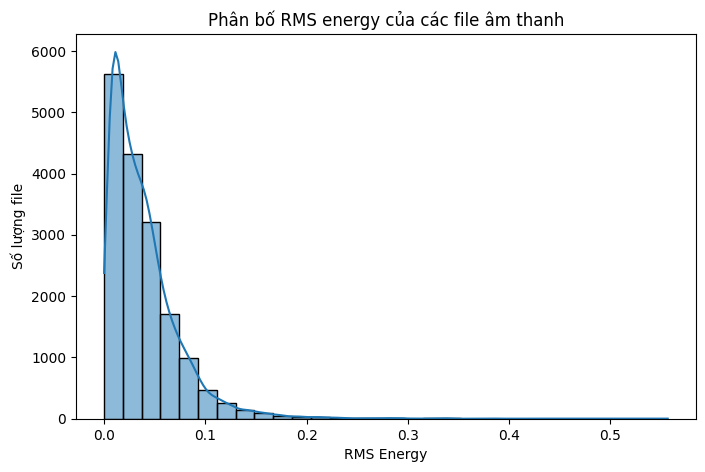

In [38]:
rms_values = []

for y in audio_set['audio']:
    rms = librosa.feature.rms(y=y).mean()
    rms_values.append(rms)

audio_set['rms_energy'] = rms_values
plt.figure(figsize=(8,5))
sns.histplot(audio_set['rms_energy'], bins=30, kde=True)
plt.title("Phân bố RMS energy của các file âm thanh")
plt.xlabel("RMS Energy")
plt.ylabel("Số lượng file")
plt.show()

/tmp/ipython-input-4125006598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='duration', data=audio_set, palette='Set2')


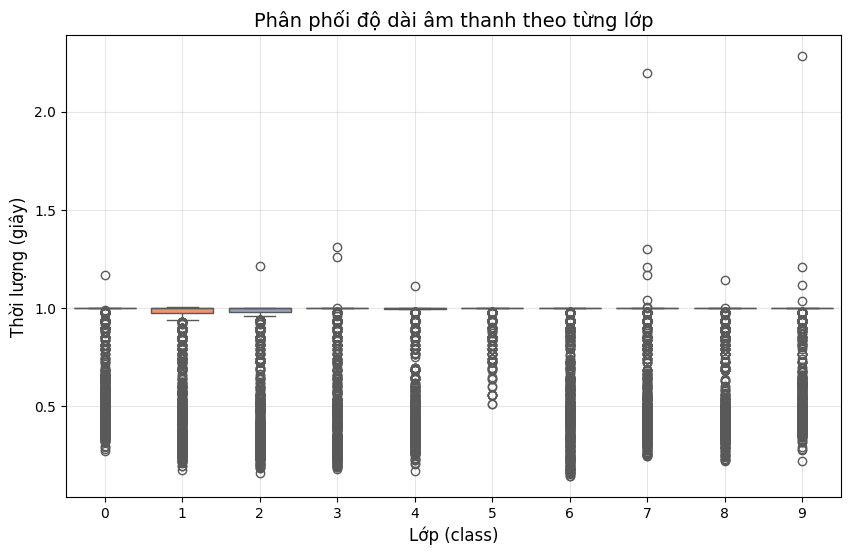

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='duration', data=audio_set, palette='Set2')
plt.title('Phân phối độ dài âm thanh theo từng lớp', fontsize=14)
plt.xlabel('Lớp (class)', fontsize=12)
plt.ylabel('Thời lượng (giây)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

**Nhận xét:**


*   Nhìn chung ta thấy được số lượng mẫu giữa các số là cân bằng.
*   Độ dài trung bình của các mẫu cũng khá tương đương nhau
*   Nhưng xét sang chỉ cố root mean square energy có thể thấy đa số file âm thanh có mức năng lượng khá thấp, có thể là do khoảng lặng ở đầu và cuối file
*   Phân phối độ dài âm thanh được dàn đều

##2.2 Phân tích dữ liệu đã dược tiền xử lý (cắt âm thanh im lặng ở đầu và cuối)

In [40]:
# Tính số lượng mẫu, độ dài trung bình, min, max theo từng lớp
stats = (
    audio_trimmed_set.groupby('class')['duration']
    .agg(['count', 'mean', 'min', 'max'])
    .reset_index()
    .rename(columns={
        'count': 'Số lượng mẫu',
        'mean': 'Độ dài trung bình (s)',
        'min': 'Độ dài nhỏ nhất (s)',
        'max': 'Độ dài lớn nhất (s)'
    })
)

print("📊 Thống kê số lượng và độ dài âm thanh theo class:")
print(stats)

📊 Thống kê số lượng và độ dài âm thanh theo class:
   class  Số lượng mẫu  Độ dài trung bình (s)  Độ dài nhỏ nhất (s)  \
0      0          1700               0.787018             0.164082   
1      1          1700               0.715249             0.094422   
2      2          1700               0.702876             0.094422   
3      3          1700               0.734304             0.164082   
4      4          1700               0.727111             0.169887   
5      5          1700               0.810122             0.071202   
6      6          1700               0.778278             0.143537   
7      7          1700               0.757811             0.187302   
8      8          1700               0.737564             0.210522   
9      9          1700               0.773775             0.094422   

   Độ dài lớn nhất (s)  
0             1.160998  
1             1.000000  
2             1.000000  
3             1.000000  
4             1.114875  
5             1.000000  
6  

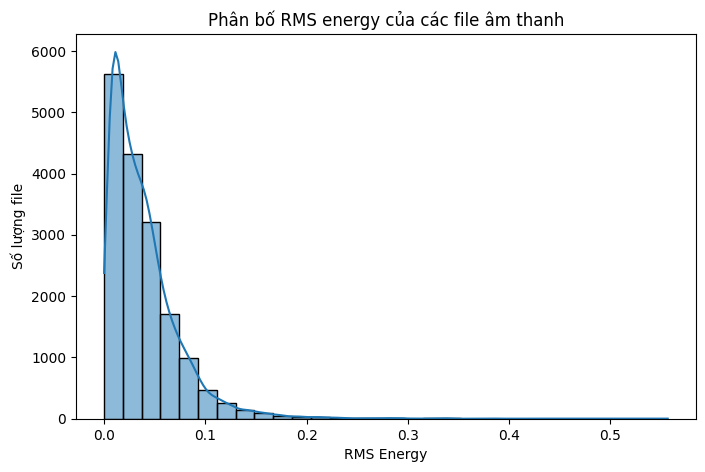

In [41]:
rms_trimmed_values = []

for y in audio_trimmed_set['audio']:
    rms = librosa.feature.rms(y=y).mean()
    rms_trimmed_values.append(rms)

audio_trimmed_set['rms_energy'] = rms_trimmed_values
plt.figure(figsize=(8,5))
sns.histplot(audio_set['rms_energy'], bins=30, kde=True)
plt.title("Phân bố RMS energy của các file âm thanh")
plt.xlabel("RMS Energy")
plt.ylabel("Số lượng file")
plt.show()

/tmp/ipython-input-3899392084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='duration', data=audio_trimmed_set, palette='Set2')


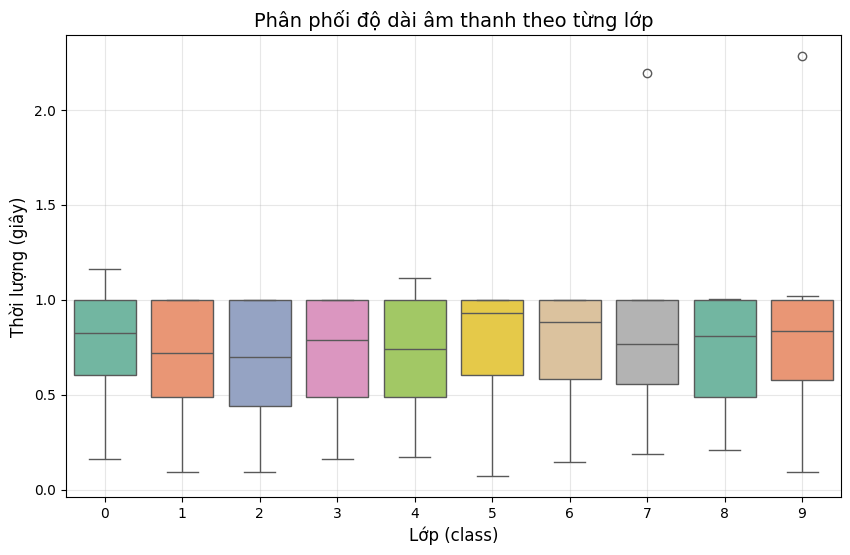

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='duration', data=audio_trimmed_set, palette='Set2')
plt.title('Phân phối độ dài âm thanh theo từng lớp', fontsize=14)
plt.xlabel('Lớp (class)', fontsize=12)
plt.ylabel('Thời lượng (giây)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


*   Nhưng xét sang chỉ cố root mean square energy có thể thấy đa số file âm thanh có mức năng lượng khá thấp mặc dù đã lọc khoảng lặng đầu cuối, có thể là du số lượng âm vô thanh trong cách phát âm các chữ số khá nhiều dẫn đến điều này
*   Phân phối độ dài âm thanh đã tập trung lại

##2.3 Quan sát hình dạng mẫu.
###2.3.1 Mẫu trên miền thời gian

Phát âm thanh cho chữ số: 0


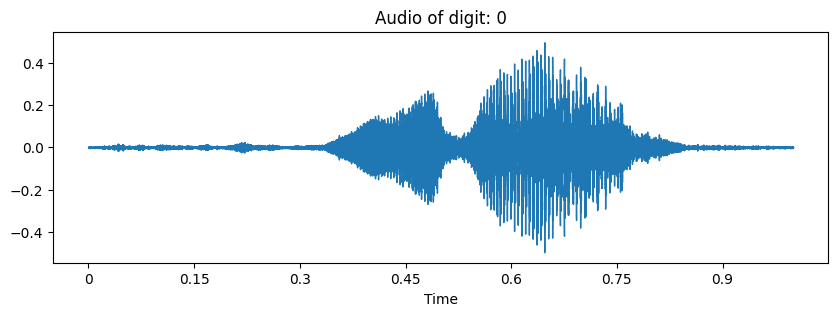

In [43]:
get_random_audio(data_path_set,0)

Phát âm thanh cho chữ số: 1


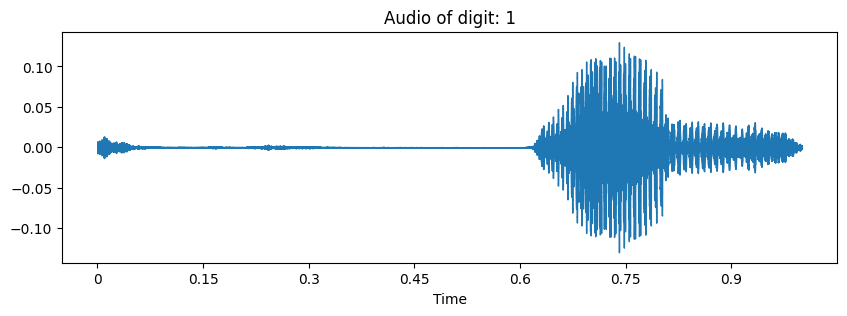

In [44]:
get_random_audio(data_path_set,1)

Phát âm thanh cho chữ số: 2


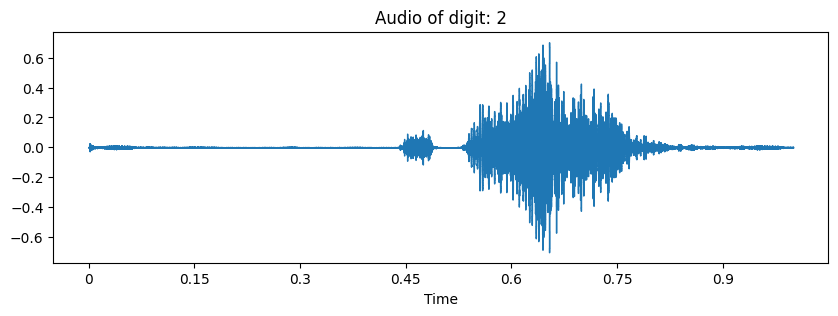

In [45]:
get_random_audio(data_path_set,2)

Phát âm thanh cho chữ số: 3


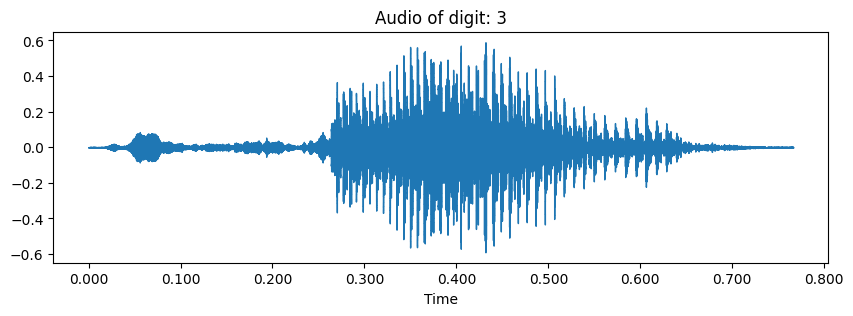

In [46]:
get_random_audio(data_path_set,3)

Phát âm thanh cho chữ số: 4


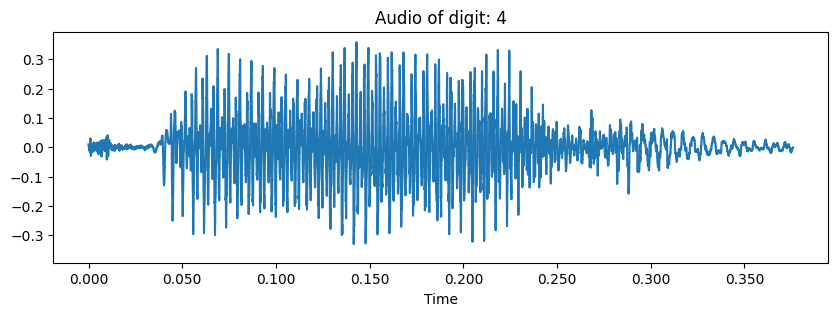

In [47]:
get_random_audio(data_path_set,4)

Phát âm thanh cho chữ số: 5


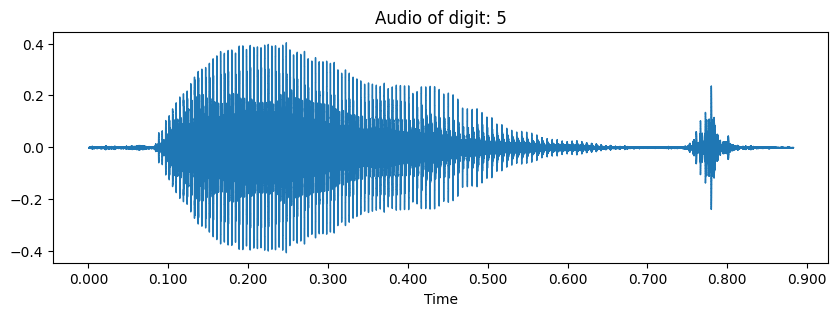

In [48]:
get_random_audio(data_path_set,5)

Phát âm thanh cho chữ số: 6


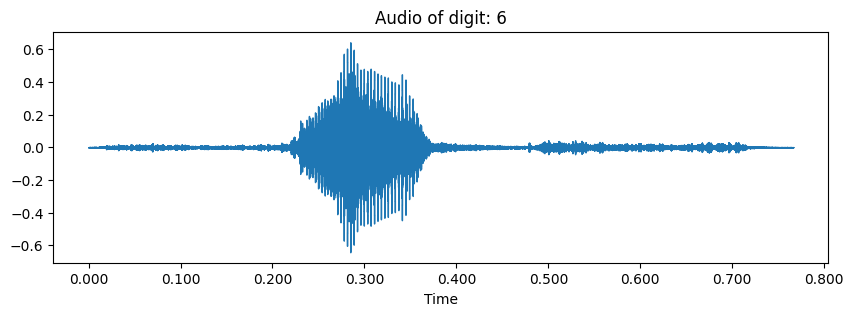

In [49]:
get_random_audio(data_path_set,6)

Phát âm thanh cho chữ số: 7


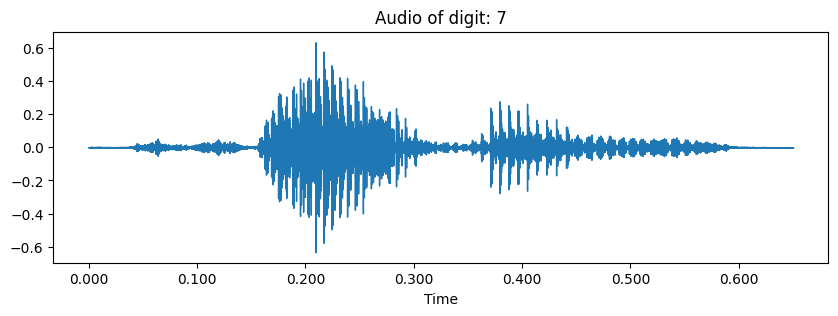

In [50]:
get_random_audio(data_path_set,7)

Phát âm thanh cho chữ số: 8


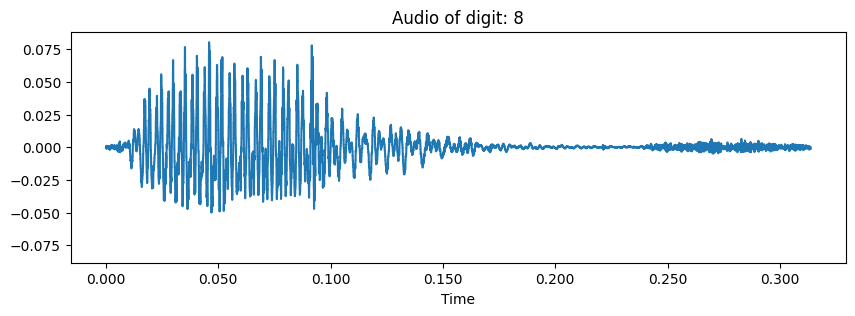

In [51]:
get_random_audio(data_path_set,8)

Phát âm thanh cho chữ số: 9


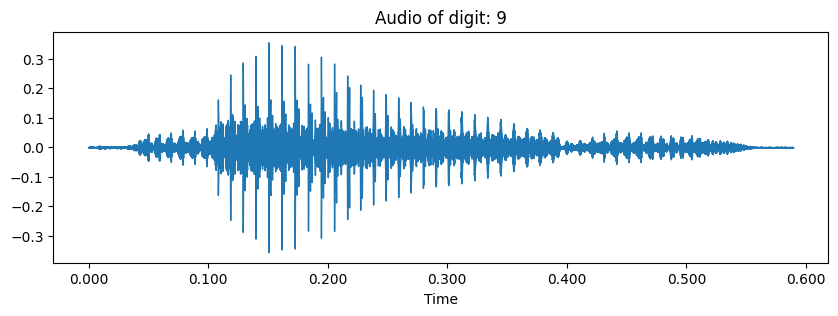

In [52]:
get_random_audio(data_path_set,9)

###2.3.2 Mẫu trên miền thời gian - tần số

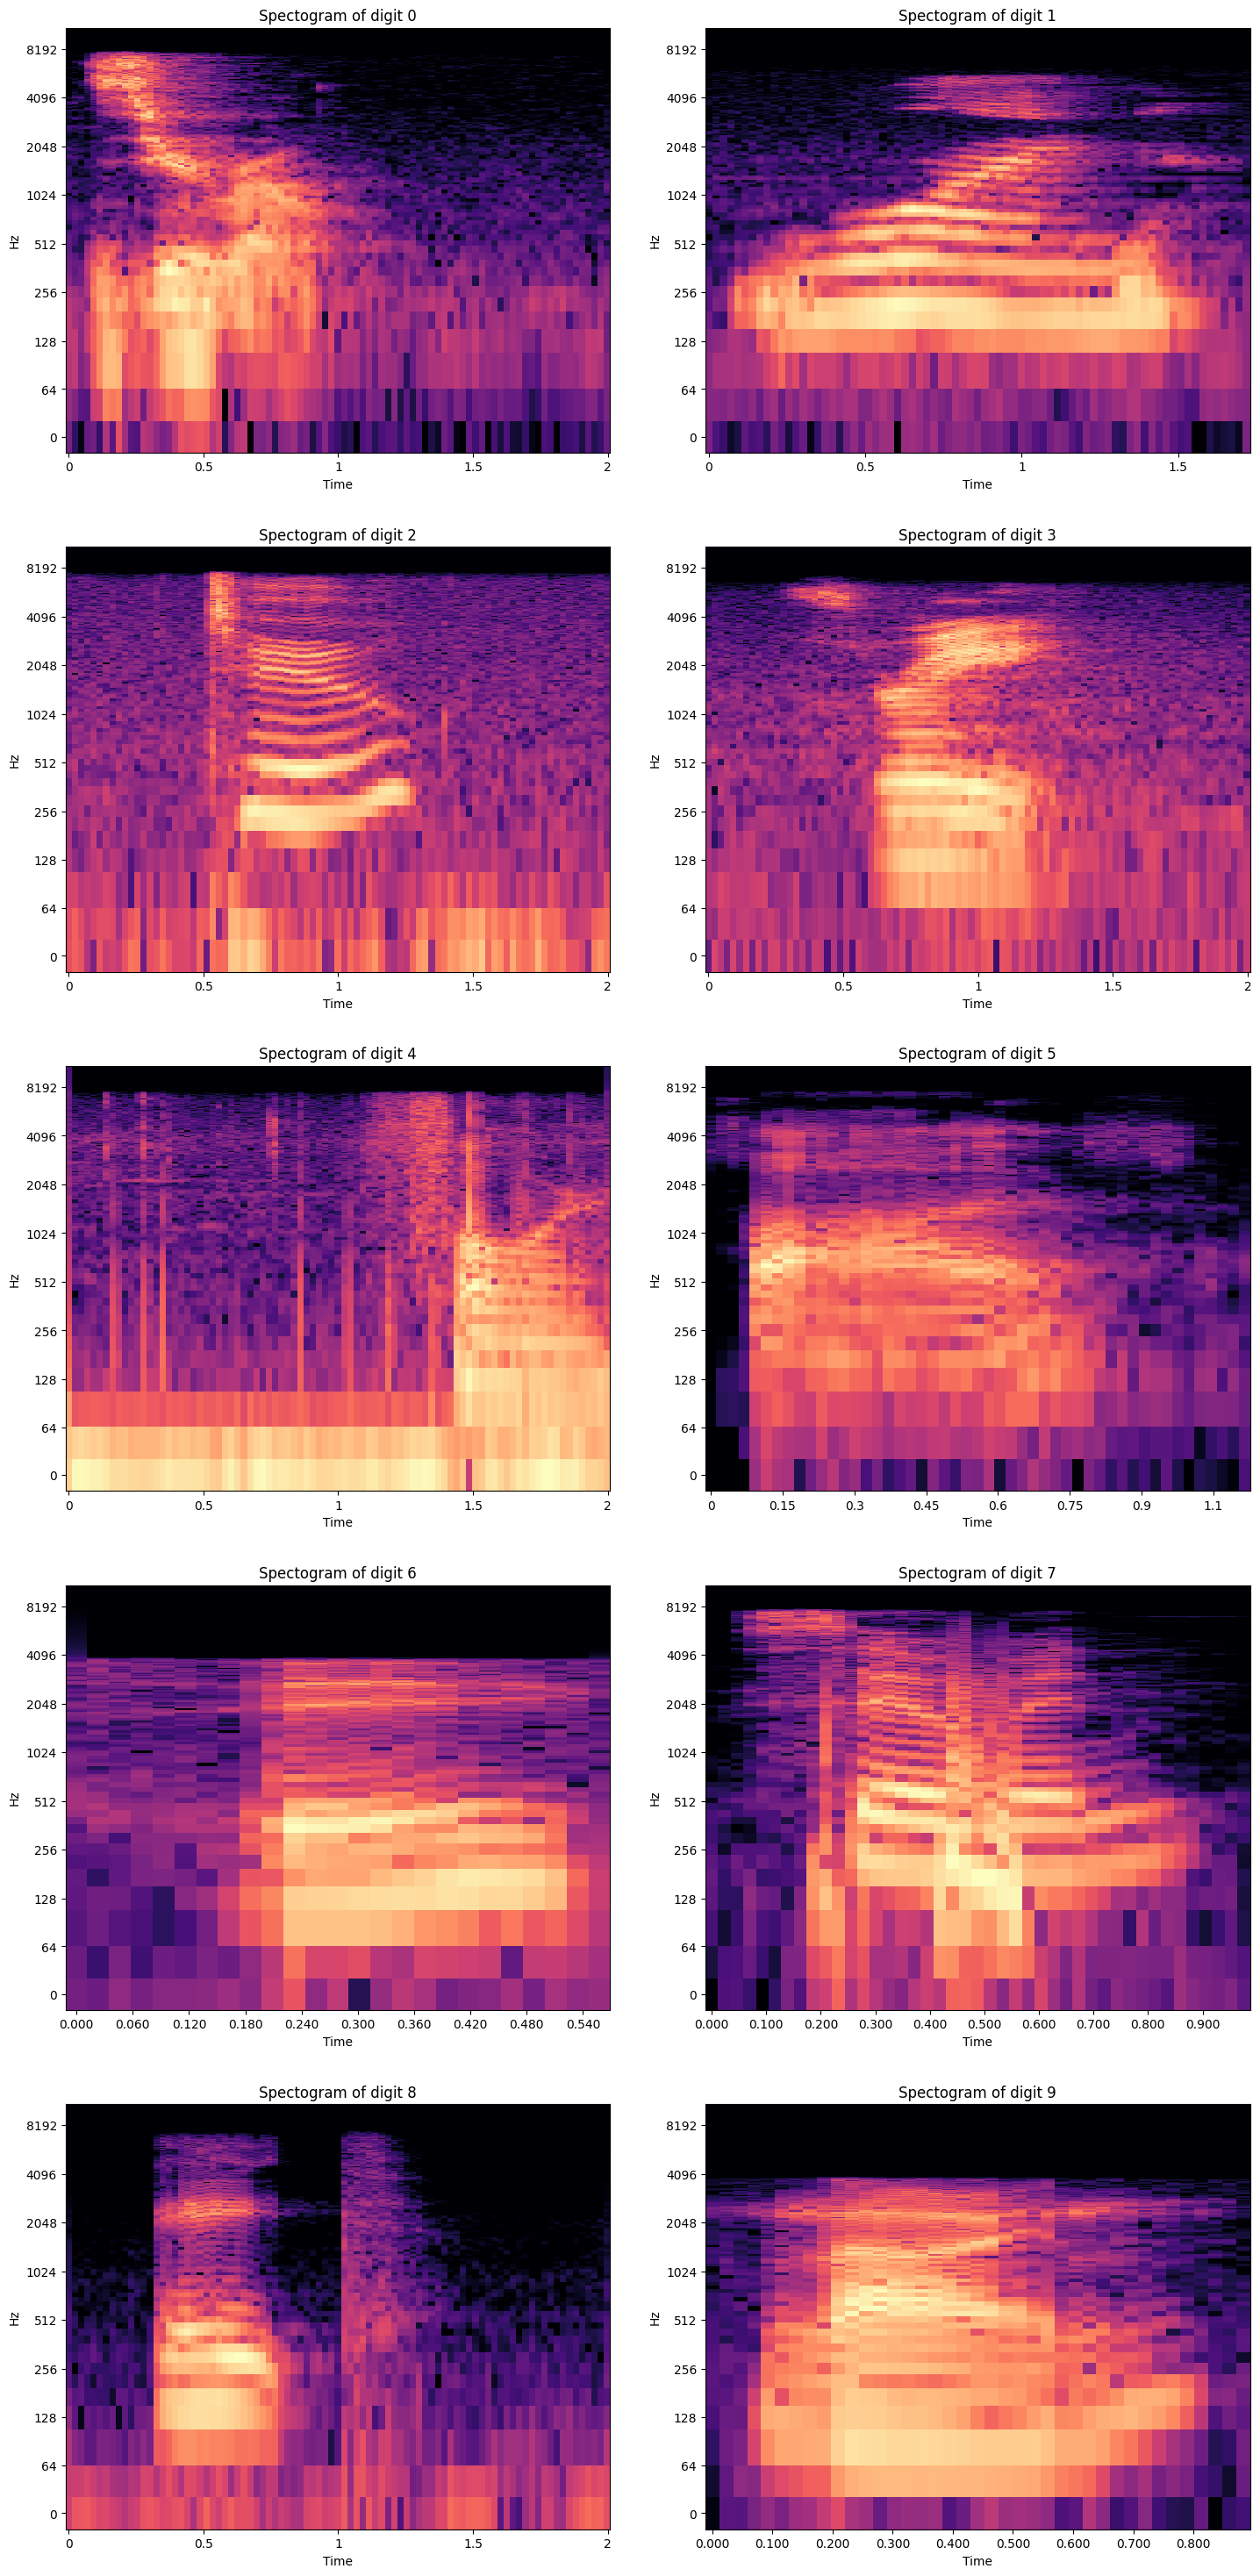

In [53]:
get_audio_spectogram(data_path_set)

###2.3.3 Mẫu trên miền thời gian - MFCC

Shape of MFCC of audio digit 0 --->  (13, 67)
Shape of MFCC of audio digit 1 --->  (13, 57)
Shape of MFCC of audio digit 2 --->  (13, 34)
Shape of MFCC of audio digit 3 --->  (13, 87)
Shape of MFCC of audio digit 4 --->  (13, 20)
Shape of MFCC of audio digit 5 --->  (13, 87)
Shape of MFCC of audio digit 6 --->  (13, 57)
Shape of MFCC of audio digit 7 --->  (13, 63)
Shape of MFCC of audio digit 8 --->  (13, 39)
Shape of MFCC of audio digit 9 --->  (13, 43)


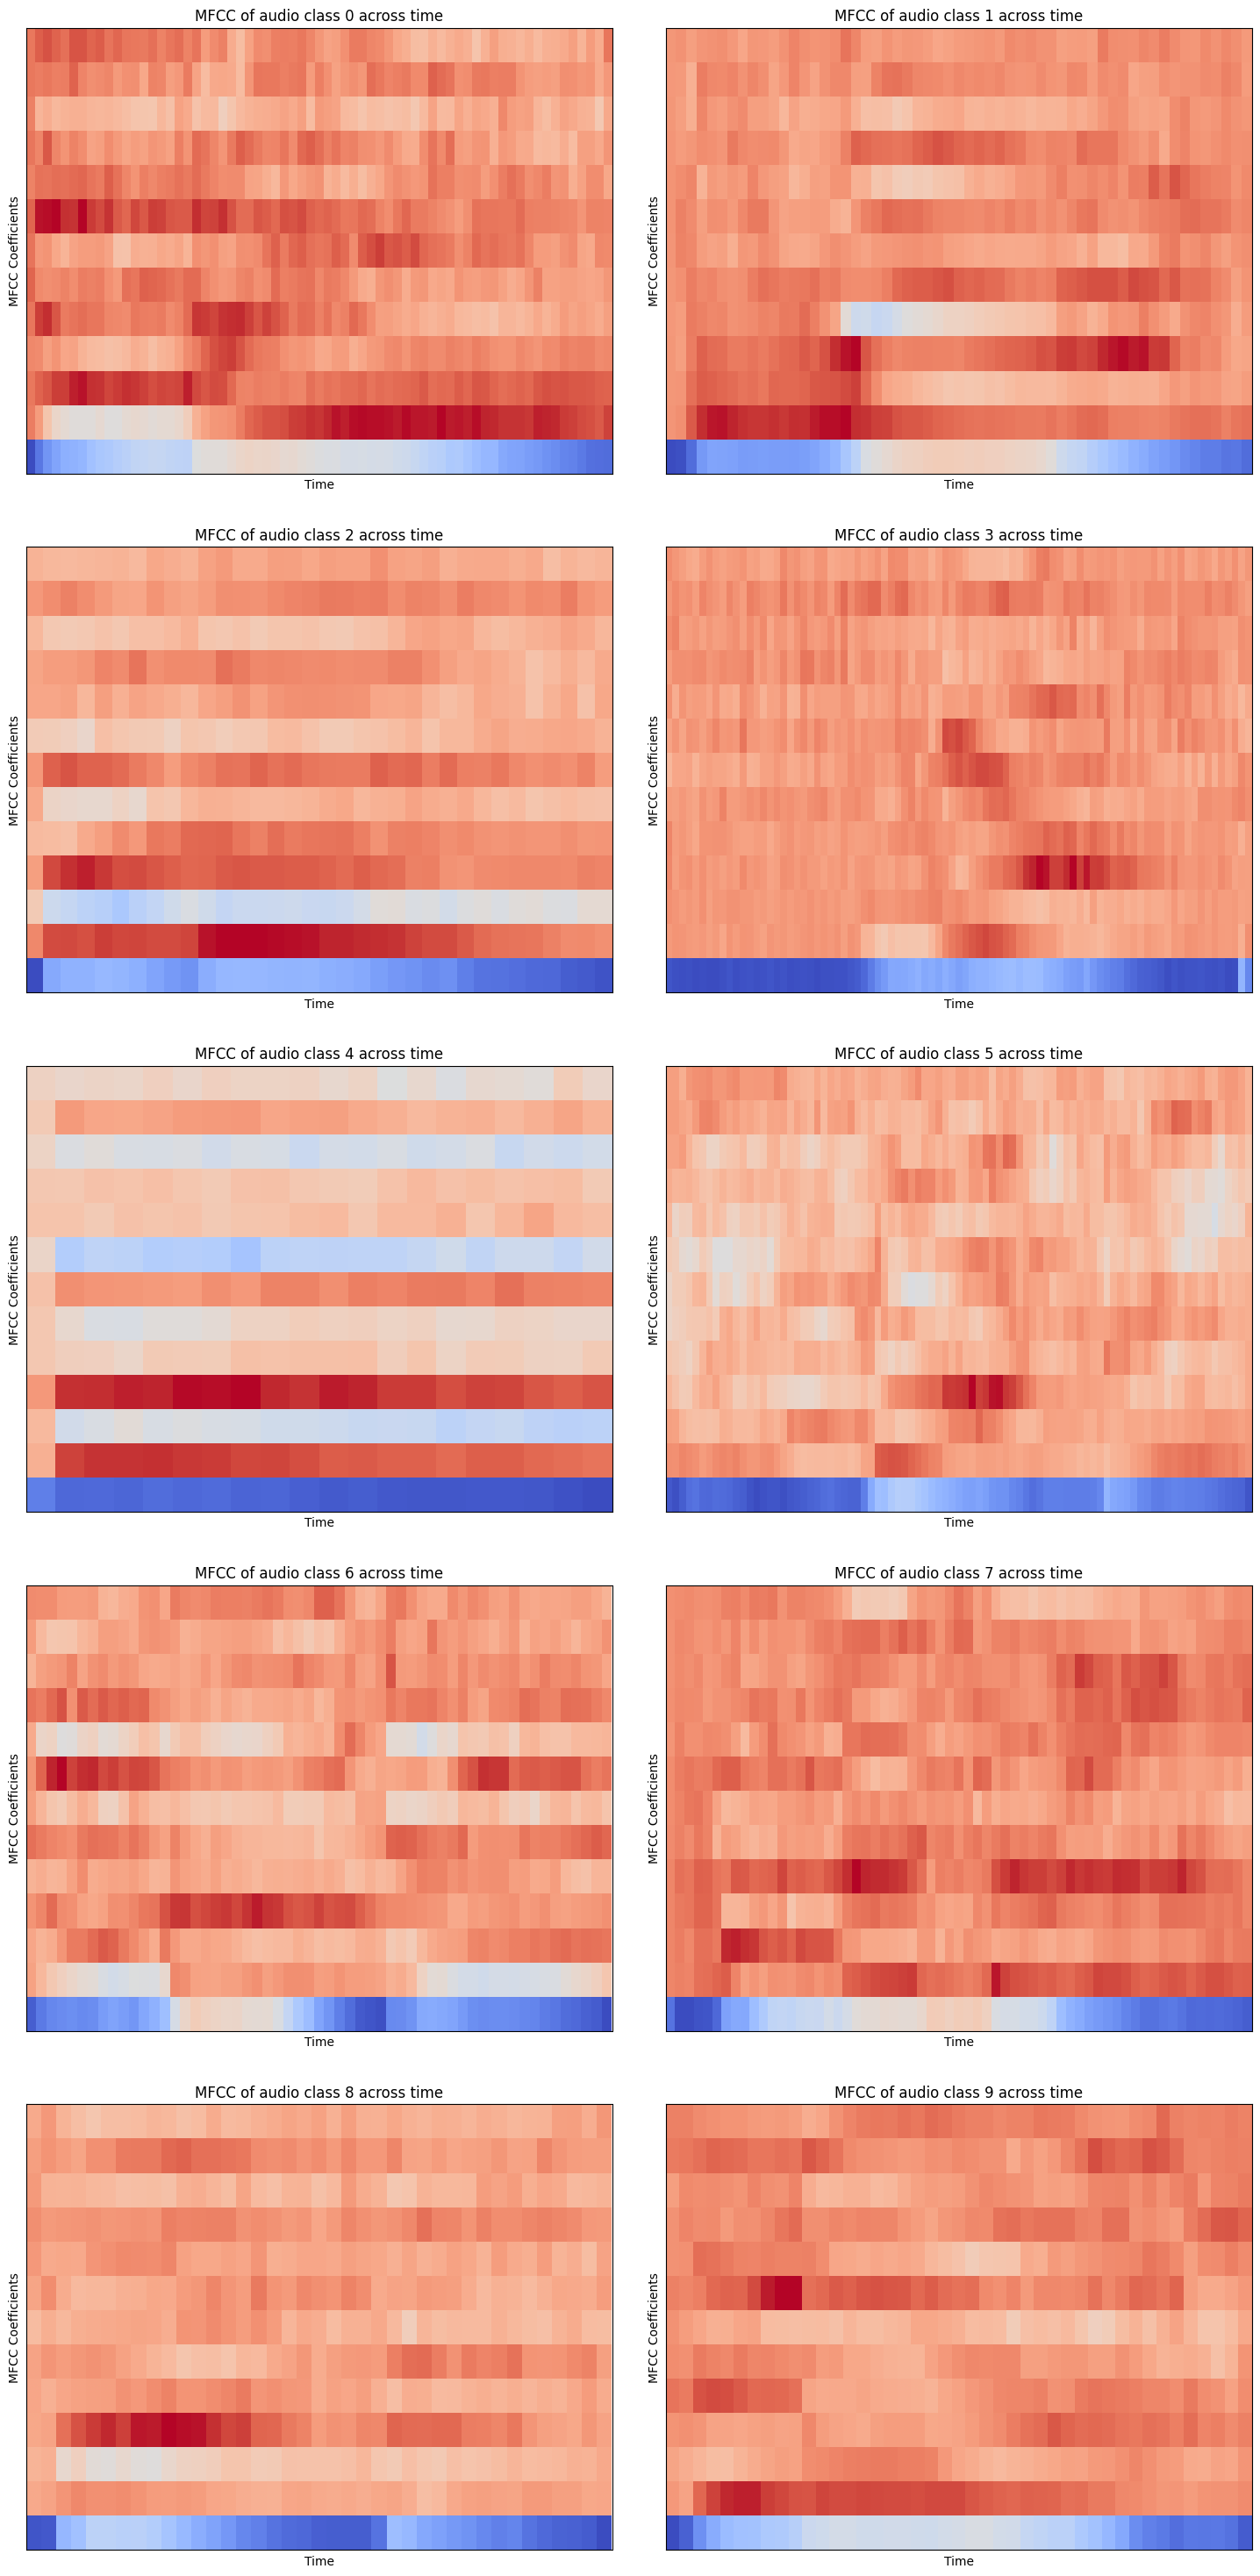

In [54]:
get_audio_mfcc(data_path_set)

#3.Trích xuất đặc trưng(Feature Embedding)

**Trích xuất đặc trưng**

In [55]:
# Gọi hàm để bắt đầu quá trình
read_dataset_and_save_feture(root_folder_path=DATA_FOLDER, save_path=SAVE_FILE_PATH_NPZ)

Processing Labels:  73%|███████▎  | 8/11 [01:04<00:24,  8.27s/it]

Lỗi khi xử lý file ./HPMR/spoken_digit_data/five/f953e1af_nohash_0.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=7


Processing Labels: 100%|██████████| 11/11 [01:32<00:00,  8.37s/it]



Trích xuất hoàn tất! Đã lưu 16999 chuỗi đặc trưng.


**Chia tập dữ liệu và lấy scaler**

In [56]:
from modules.preprocessing import load_and_preprocess_data
from modules.preprocessing import split_train_test

# Đường dẫn đến file dữ liệu
DATA_FILE_PATH_NPZ = './HPMR/features/processed_data.npz'

# 1. Tải và tiền xử lý
X_processed, y_processed, class_names = load_and_preprocess_data(DATA_FILE_PATH_NPZ)

# 2. Chia dữ liệu
X_train, X_test, y_train, y_test, scaler = split_train_test(X_processed, y_processed)

#4.Huấn luyện mô hình(Model Training) và đánh giá (Evaluate)

In [ ]:
from modules.training import train_hmm, evaluate_hmm, save_model
import os
import pickle

# Huấn luyện mô hình
models = train_hmm(
    X_train=X_train,
    y_train=y_train,
    class_names=class_names,
    num_states=7,
    n_loop=45,
    tol=1e-3
)

In [ ]:
# Đánh giá mô hình
metrics = evaluate_hmm(
    models=models,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names
)

In [ ]:
# Lưu mô hình, scaler và metrics
save_path = save_model(
    models=models,
    scaler=scaler,  # scaler đã được fit ở bước chuẩn hóa dữ liệu trước đó
    metrics=metrics,
    save_dir='./HPMR/models',
    model_name=None
)

print(f"\n🎉 Mô hình đã được lưu tại: {save_path}")